Keras

In [8]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Build MLP
model = Sequential([
    Dense(4, activation='tanh', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)

# Train
model.fit(X, y, epochs=500, verbose=0)

# Evaluate
predictions = model.predict(X)
print("Keras Predictions:")
print(np.round(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Keras Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


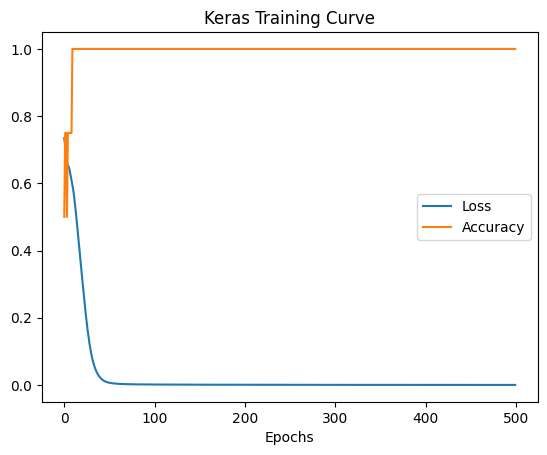

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


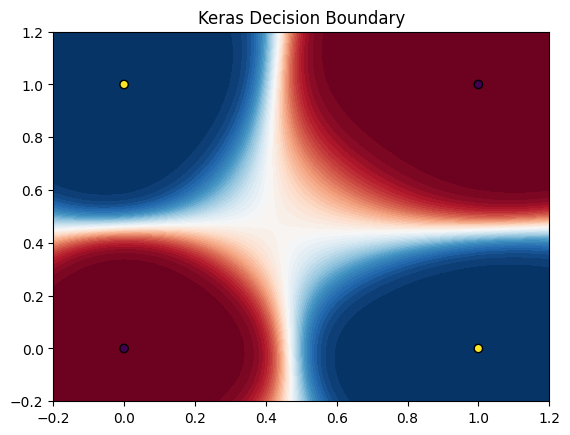

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Model
model = Sequential([
    Dense(4, activation='tanh', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(X, y, epochs=500, verbose=0)

# Training Curve
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title("Keras Training Curve")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.2,1.2,100),
                     np.linspace(-0.2,1.2,100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='RdBu')
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("Keras Decision Boundary")
plt.show()

PyTorch

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model = MLP()

# Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Training
for epoch in range(500):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

# Evaluation
print("PyTorch Predictions:")
print(torch.round(model(X)).detach().numpy())

PyTorch Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


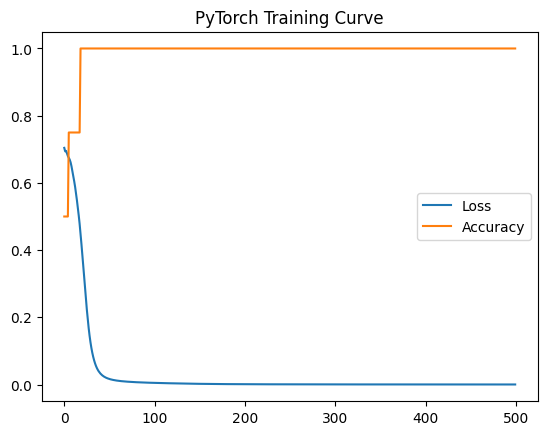

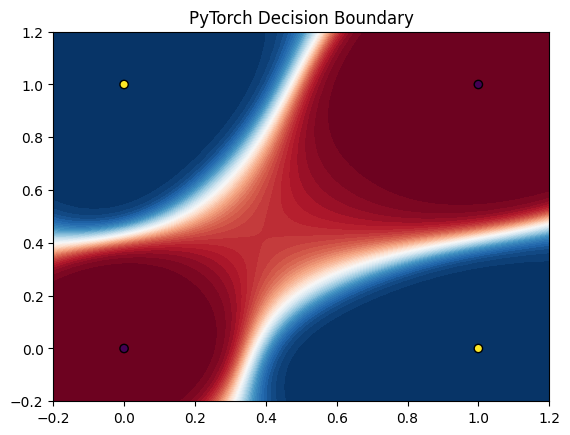

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

model = MLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

losses = []
accuracies = []

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

    preds = torch.round(outputs)
    acc = (preds == y).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

# Training Curve
plt.plot(losses, label='Loss')
plt.plot(accuracies, label='Accuracy')
plt.title("PyTorch Training Curve")
plt.legend()
plt.show()

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.2,1.2,100),
                     np.linspace(-0.2,1.2,100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z = model(grid).detach().numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='RdBu')
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("PyTorch Decision Boundary")
plt.show()


Tensor Flow

In [12]:
import tensorflow as tf
import numpy as np

# XOR dataset
X = tf.constant([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = tf.constant([[0.],[1.],[1.],[0.]])

# Initialize weights
W1 = tf.Variable(tf.random.normal([2, 4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4, 1]))
b2 = tf.Variable(tf.zeros([1]))

optimizer = tf.optimizers.Adam(learning_rate=0.1)

# Training loop
for epoch in range(500):
    with tf.GradientTape() as tape:
        hidden = tf.tanh(tf.matmul(X, W1) + b1)
        output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, output))

    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

# Evaluation
print("TensorFlow Low-Level Predictions:")
print(tf.round(output).numpy())

TensorFlow Low-Level Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


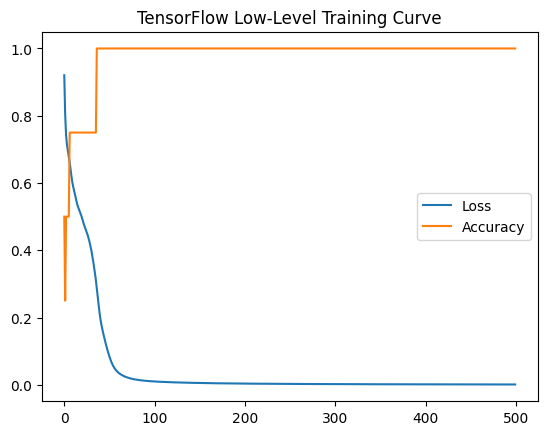

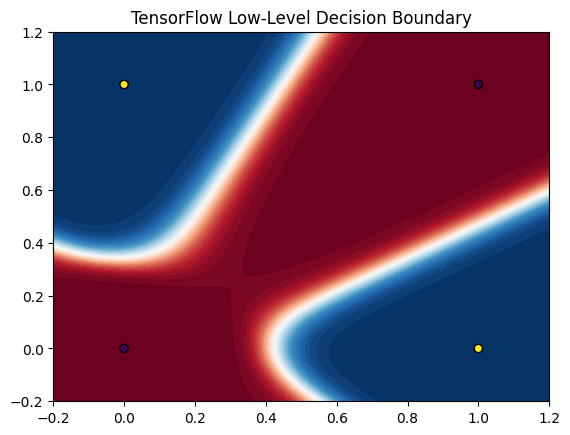

In [13]:
import tensorflow as tf

X = tf.constant([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = tf.constant([[0.],[1.],[1.],[0.]])

W1 = tf.Variable(tf.random.normal([2,4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4,1]))
b2 = tf.Variable(tf.zeros([1]))

optimizer = tf.optimizers.Adam(learning_rate=0.1)

losses = []
accuracies = []

for epoch in range(500):
    with tf.GradientTape() as tape:
        h = tf.tanh(tf.matmul(X, W1) + b1)
        out = tf.sigmoid(tf.matmul(h, W2) + b2)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, out))

    grads = tape.gradient(loss, [W1,b1,W2,b2])
    optimizer.apply_gradients(zip(grads,[W1,b1,W2,b2]))

    preds = tf.round(out)
    acc = tf.reduce_mean(tf.cast(preds == y, tf.float32))

    losses.append(loss.numpy())
    accuracies.append(acc.numpy())

# Training Curve
plt.plot(losses, label='Loss')
plt.plot(accuracies, label='Accuracy')
plt.title("TensorFlow Low-Level Training Curve")
plt.legend()
plt.show()

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.2,1.2,100),
                     np.linspace(-0.2,1.2,100))
grid = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)
h = tf.tanh(tf.matmul(grid, W1) + b1)
Z = tf.sigmoid(tf.matmul(h, W2) + b2).numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='RdBu')
plt.scatter(X[:,0], X[:,1], c=y.numpy().flatten(), edgecolors='k')
plt.title("TensorFlow Low-Level Decision Boundary")
plt.show()
